In [1]:
# ============================================================
# CELL 1 — GOOGLE DRIVE
# ============================================================

from google.colab import drive

drive.mount('/content/drive')

print("Google Drive mounted successfully.")

Mounted at /content/drive
Google Drive mounted successfully.


In [2]:
# ============================================================
# CELL 2 — IMPORTS
# ============================================================

import os
import math
import time

from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F

print("Imports successful.")

Imports successful.


In [3]:
# ============================================================
# CELL 3 — MODEL CONFIGURATION
# ============================================================

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/AI_Training/Models"
)

MODEL_PATH = (
    PROJECT_ROOT
    / "LPSR_Retraining"
    / "checkpoints"
    / "lpsr_retrained_best.pth"
)

print("Model path:")
print(MODEL_PATH)

if not MODEL_PATH.exists():

    raise FileNotFoundError(
        f"""
LPSR model not found:

{MODEL_PATH}

Please check that lpsr_best.pth exists in:
My Drive/car_detection/LPSR/checkpoints/
"""
    )

print()
print("✓ LPSR model found")

size_mb = MODEL_PATH.stat().st_size / (1024 * 1024)

print(
    f"✓ Model size: {size_mb:.2f} MB"
)

Model path:
/content/drive/MyDrive/AI_Training/Models/LPSR_Retraining/checkpoints/lpsr_retrained_best.pth

✓ LPSR model found
✓ Model size: 7.68 MB


In [4]:
# ============================================================
# CELL 4 — DEVICE
# ============================================================

DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("=" * 60)
print("DEVICE")
print("=" * 60)

print("Device:", DEVICE)

if DEVICE.type == "cuda":

    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

    print(
        "CUDA:",
        torch.version.cuda
    )

print("=" * 60)

DEVICE
Device: cuda
GPU: Tesla T4
CUDA: 12.8


In [5]:
# ============================================================
# CELL 5 — LPSR ARCHITECTURE
# ============================================================

class RDB(nn.Module):

    def __init__(
        self,
        channels=64,
        growth=32,
        num_layers=4
    ):

        super().__init__()

        self.layers = nn.ModuleList()

        for i in range(num_layers):

            in_channels = (
                channels + i * growth
            )

            self.layers.append(
                nn.Conv2d(
                    in_channels,
                    growth,
                    kernel_size=3,
                    padding=1
                )
            )

        self.local_fusion = nn.Conv2d(
            channels + num_layers * growth,
            channels,
            kernel_size=1
        )

    def forward(self, x):

        features = [x]

        for layer in self.layers:

            inp = torch.cat(
                features,
                dim=1
            )

            out = F.relu(
                layer(inp),
                inplace=True
            )

            features.append(out)

        fused = self.local_fusion(
            torch.cat(
                features,
                dim=1
            )
        )

        return fused + x


class ChannelAttention(nn.Module):

    def __init__(
        self,
        channels,
        reduction=16
    ):

        super().__init__()

        hidden = max(
            channels // reduction,
            4
        )

        self.avg_pool = (
            nn.AdaptiveAvgPool2d(1)
        )

        self.fc = nn.Sequential(

            nn.Conv2d(
                channels,
                hidden,
                kernel_size=1
            ),

            nn.ReLU(
                inplace=True
            ),

            nn.Conv2d(
                hidden,
                channels,
                kernel_size=1
            ),

            nn.Sigmoid()
        )

    def forward(self, x):

        attention = self.avg_pool(x)

        attention = self.fc(
            attention
        )

        return x * attention


class SpatialAttention(nn.Module):

    def __init__(self):

        super().__init__()

        self.conv = nn.Conv2d(
            2,
            1,
            kernel_size=7,
            padding=3
        )

    def forward(self, x):

        avg = torch.mean(
            x,
            dim=1,
            keepdim=True
        )

        maximum = torch.max(
            x,
            dim=1,
            keepdim=True
        )[0]

        combined = torch.cat(
            [avg, maximum],
            dim=1
        )

        attention = torch.sigmoid(
            self.conv(combined)
        )

        return x * attention


class CSARBlock(nn.Module):

    def __init__(
        self,
        channels=64
    ):

        super().__init__()

        self.rdb = RDB(
            channels=channels
        )

        self.channel_attention = (
            ChannelAttention(channels)
        )

        self.spatial_attention = (
            SpatialAttention()
        )

    def forward(self, x):

        residual = x

        x = self.rdb(x)

        x = self.channel_attention(x)

        x = self.spatial_attention(x)

        return x + residual


class TraffiqLPSR(nn.Module):

    def __init__(
        self,
        in_channels=3,
        out_channels=3,
        features=64,
        num_blocks=4
    ):

        super().__init__()

        self.head = nn.Conv2d(
            in_channels,
            features,
            kernel_size=3,
            padding=1
        )

        self.blocks = nn.ModuleList([

            CSARBlock(
                channels=features
            )

            for _ in range(num_blocks)

        ])

        self.global_fusion = nn.Conv2d(
            features * num_blocks,
            features,
            kernel_size=1
        )

        self.global_conv = nn.Conv2d(
            features,
            features,
            kernel_size=3,
            padding=1
        )

        self.reconstruction = nn.Sequential(

            nn.Conv2d(
                features,
                features,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(
                inplace=True
            ),

            nn.Conv2d(
                features,
                out_channels,
                kernel_size=3,
                padding=1
            )
        )

    def forward(self, x):

        residual = x

        x = self.head(x)

        block_outputs = []

        for block in self.blocks:

            x = block(x)

            block_outputs.append(x)

        fused = torch.cat(
            block_outputs,
            dim=1
        )

        fused = self.global_fusion(
            fused
        )

        fused = self.global_conv(
            fused
        )

        output = self.reconstruction(
            fused
        )

        output = output + residual

        return output.clamp(
            0,
            1
        )


print("✓ TraffIQ LPSR architecture defined.")

✓ TraffIQ LPSR architecture defined.


In [6]:
# ============================================================
# CELL 6 — LOAD TRAINED LPSR
# ============================================================

model = TraffiqLPSR()

checkpoint = torch.load(
    MODEL_PATH,
    map_location=DEVICE
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model = model.to(DEVICE)

model.eval()

print("=" * 60)
print("TRAINED LPSR LOADED")
print("=" * 60)

print(
    "Checkpoint epoch:",
    checkpoint.get("epoch", "unknown")
)

print(
    "Best validation loss:",
    checkpoint.get(
        "best_val_loss",
        "unknown"
    )
)

print("Status: READY")
print("=" * 60)

TRAINED LPSR LOADED
Checkpoint epoch: 59
Best validation loss: 0.04975690930601089
Status: READY


In [ ]:
# ============================================================
# CELL 7 — UPLOAD TEST LICENSE PLATE
# ============================================================

from google.colab import files

uploaded = files.upload()

if len(uploaded) == 0:

    raise RuntimeError(
        "No image was uploaded."
    )

IMAGE_PATH = Path(
    "/content"
) / next(iter(uploaded.keys()))

print("=" * 60)
print("IMAGE UPLOADED")
print("=" * 60)

print("File:")
print(IMAGE_PATH)

print("=" * 60)

TypeError: 'NoneType' object is not subscriptable

In [24]:
# ============================================================
# CELL 8 — PREPROCESS IMAGE
# ============================================================

IMAGE_H = 64
IMAGE_W = 256


def prepare_input(image_path):

    image = Image.open(
        image_path
    ).convert("RGB")

    original_size = image.size

    # Preserve aspect ratio
    scale = min(
        IMAGE_W / image.width,
        IMAGE_H / image.height
    )

    new_width = max(
        1,
        int(image.width * scale)
    )

    new_height = max(
        1,
        int(image.height * scale)
    )

    image_resized = image.resize(
        (new_width, new_height),
        Image.Resampling.LANCZOS
    )

    # Black canvas
    canvas = Image.new(
        "RGB",
        (IMAGE_W, IMAGE_H),
        (0, 0, 0)
    )

    x = (
        IMAGE_W - new_width
    ) // 2

    y = (
        IMAGE_H - new_height
    ) // 2

    canvas.paste(
        image_resized,
        (x, y)
    )

    # Convert to tensor
    arr = np.asarray(
        canvas
    ).astype(
        np.float32
    ) / 255.0

    tensor = torch.from_numpy(
        arr
    )

    tensor = tensor.permute(
        2,
        0,
        1
    )

    tensor = tensor.unsqueeze(
        0
    )

    return (
        image,
        canvas,
        tensor
    )


original_image, prepared_image, input_tensor = (
    prepare_input(IMAGE_PATH)
)

print("Original size:", original_image.size)

print(
    "Model input:",
    tuple(input_tensor.shape)
)

print("=" * 60)

Original size: (61, 18)
Model input: (1, 3, 64, 256)


In [25]:
# ============================================================
# CELL 9 — LPSR INFERENCE
# ============================================================

model.eval()

input_tensor = input_tensor.to(
    DEVICE
)

start_time = time.time()

with torch.no_grad():

    output_tensor = model(
        input_tensor
    )

inference_time = (
    time.time() - start_time
)

output_tensor = (
    output_tensor
    .squeeze(0)
    .cpu()
    .clamp(0, 1)
)

print("=" * 60)
print("LPSR INFERENCE COMPLETE")
print("=" * 60)

print(
    "Inference time:",
    f"{inference_time * 1000:.2f} ms"
)

print(
    "Output shape:",
    tuple(output_tensor.shape)
)

print("=" * 60)

LPSR INFERENCE COMPLETE
Inference time: 6.11 ms
Output shape: (3, 64, 256)


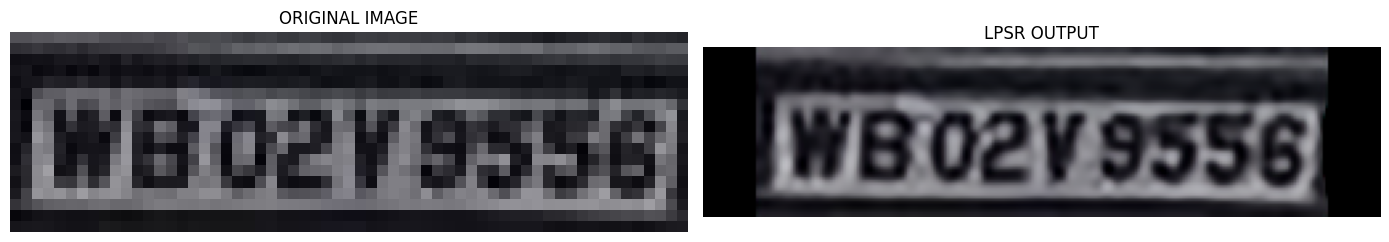

In [26]:
# ============================================================
# CELL 10 — DISPLAY LPSR RESULT
# ============================================================

output_image = (
    output_tensor
    .permute(1, 2, 0)
    .numpy()
)

# ============================================================
# DISPLAY ORIGINAL + LPSR OUTPUT
# ============================================================

plt.figure(figsize=(14, 6))

# ------------------------------------------------------------
# Original Image
# ------------------------------------------------------------

plt.subplot(1, 2, 1)

plt.imshow(original_image)

plt.title("ORIGINAL IMAGE")

plt.axis("off")


# ------------------------------------------------------------
# LPSR Output
# ------------------------------------------------------------

plt.subplot(1, 2, 2)

plt.imshow(output_image)

plt.title("LPSR OUTPUT")

plt.axis("off")


plt.tight_layout()

plt.show()

In [ ]:
# ============================================================
# CELL 10 — SAVE / DOWNLOAD LPSR OUTPUT
# ============================================================

from google.colab import files
from PIL import Image
import numpy as np

# ------------------------------------------------------------
# Convert LPSR output tensor to image
# ------------------------------------------------------------

output_image = (
    output_tensor
    .permute(1, 2, 0)
    .numpy()
)

# Convert to uint8
output_image = np.clip(
    output_image * 255,
    0,
    255
).astype(np.uint8)

# ------------------------------------------------------------
# Save to /content
# ------------------------------------------------------------

output_path = "/content/lpsr_output.png"

Image.fromarray(
    output_image
).save(
    output_path
)

print("LPSR output saved to:")
print(output_path)

# ------------------------------------------------------------
# Download the LPSR output
# ------------------------------------------------------------

files.download(output_path)

In [ ]:
# ============================================================
# CELL 10 — DISPLAY LPSR RESULT
# ============================================================

output_image = (
    output_tensor
    .permute(1, 2, 0)
    .numpy()
)

prepared_array = np.asarray(
    prepared_image
)


plt.figure(
    figsize=(18, 6)
)

# ------------------------------------------------------------
# Original
# ------------------------------------------------------------

plt.subplot(
    1,
    3,
    1
)

plt.imshow(
    original_image
)

plt.title(
    "ORIGINAL IMAGE"
)

plt.axis("off")


# ------------------------------------------------------------
# Model input
# ------------------------------------------------------------

plt.subplot(
    1,
    3,
    2
)

plt.imshow(
    prepared_array
)

plt.title(
    "LPSR INPUT (64 × 256)"
)

plt.axis("off")


# ------------------------------------------------------------
# LPSR output
# ------------------------------------------------------------

plt.subplot(
    1,
    3,
    3
)

plt.imshow(
    output_image
)

plt.title(
    "LPSR OUTPUT"
)

plt.axis("off")


plt.tight_layout()

plt.show()